#MAJOR PROJECT 1
#PROJECT TITLE: DATA DRIVEN SOCIAL ENGAGEMENT INITIATIVE
##MODULE 1: DATA EXTRACTION

In [2]:
#generate content performance data
import pandas as pd
import numpy as np
np.random.seed(42)
n_posts = 100
topics = ['Social Anxiety','Dating','Carrer Stress','Imposter Syndrome','Friendship']
formats = ['Short Video','Long Video','Carousel','Static Image']
content_data = pd.DataFrame({
    'Post_ID':[f'POST_{i:03d}' for i in range(1, n_posts + 1)],
    'Topic': np.random.choice(topics, n_posts),
    'Format': np.random.choice(formats, n_posts),
    'Likes': np.random.randint(500, 5000, n_posts),
    'Shares': np.random.randint(50, 1500, n_posts),
    'Saves': np.random.randint(100, 2000, n_posts),
    'Retention_Rate': np.random.uniform(0.3, 0.85, n_posts),
    'Follower_Growth': np.random.randint(10, 500, n_posts)
})
#Sample comments for sentiment analysis
comments_pool = {
    'Social Anxiety': ["This is so relatable, I feel seen", "Honestly, thought I was the only one", "Meh, okay post"],
    'Dating': ["Too accurate it hurts", "Not sure I agree with dating advice","Just Standard Stuff"],
    'Carrer Stress': ["I needed this today, drowning at work", "This completely changed my perspective","Fine I guess"]
}
comments_data=[]
for idx, row in content_data.iterrows():
  topic = row['Topic']
  pool = comments_pool.get(topic, ["Great Post!","Interesting perspective","Nice colour scheme"])
  for i in range(3):
    comments_data.append({
        'Post_ID': row['Post_ID'],
        'Comment_Text': np.random.choice(pool)
    })
comments_df = pd.DataFrame(comments_data)
#save to csv file
content_data.to_csv('content_performance.csv', index=False)
comments_df.to_csv('user_comments.csv',index=False)
print("Datasets successfully generated!")

Datasets successfully generated!


##MODULE 2 - VIRALITY ENGINE, MODULE 3 - SENTIMENT ANALYZER, MODULE 4 - A/B TESTING

In [3]:
import pandas as pd
from textblob import TextBlob
from scipy.stats import ttest_ind
#data sets loading step
df_content = pd.read_csv('content_performance.csv')
df_comments = pd.read_csv('user_comments.csv')
#module 2 - virality prediction engine
# used formula: (shares * 3) + (saves * 2) + Likes
df_content['Viral_Coefficient'] = (df_content['Shares'] * 3) + (df_content['Saves'] * 2) + df_content['Likes']
#module 3 - Audience sentiment analyzer
relatable_triggers = ['relatable', 'feel seen', 'accurate', 'needed this', 'me today', 'drowning', 'thought i was the only one']
def analyze_sentiment(text):
  text_lower = str(text).lower()
  has_trigger = any(trigger in text_lower for trigger in relatable_triggers)
  analysis = TextBlob(text_lower)
  if analysis.sentiment.polarity > 0.1 or has_trigger:
    return "Relatable"
  else:
    return "Neutral"
df_comments['Sentiment'] = df_comments['Comment_Text'].apply(analyze_sentiment)
#module 4 - A/B testing framework
short_video = df_content[df_content['Format'] == 'Short Video']['Viral_Coefficient']
long_video = df_content[df_content['Format'] == 'Long Video']['Viral_Coefficient']
if len(short_video) > 1 and len(long_video) > 1:
  t_stat, p_val = ttest_ind(short_video, long_video)
  p_val_text = f"{p_val:.4f}"
else:
  p_val_text = "Not enough data variation to calculate"
#save
df_content.to_csv('processed_performance.csv', index=False)
df_comments.to_csv('processed_comments.csv',index=False)
print(f"Analytics computed. A/B Test P-Value: {p_val_text}")


Analytics computed. A/B Test P-Value: 0.2835


##MODULE 5 - ENGAGEMENT OPTIMIZATION RECOMMENDER,MODULE 6 - GROWTH VISUALIZATION DASHBOARD,MODULE 7 - TREND FORECASTING MODULE

In [4]:
pip install streamlit plotly pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.6 MB/s eta 0:00:00


In [5]:
%%writefile MAJOR_PROJECT1_SINDUJA.py
import streamlit as st
import pandas as pd
import plotly.express as px
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("streamlit.runtime.scriptrunner").setLevel(logging.ERROR)
st.set_page_config(layout="wide")
st.title("Data-driven Social Engagement Dashboard")
#calculated data loading step
df_content = pd.read_csv('processed_performance.csv')
df_comments = pd.read_csv('processed_comments.csv')
#metrics=row 1
st.header("Core Growth Metrics")
col1, col2, col3 = st.columns(3)
col1.metric("Total Likes analyzed", f"{int(df_content['Likes'].sum()):,}")
col2.metric("Top Viral Topic", df_content.groupby('Topic')['Viral_Coefficient'].mean().idxmax())
relatable_pct = (df_comments['Sentiment'] == 'Relatable').mean() * 100
col3.metric("Relatable Comments Rate", f"{relatable_pct:.1f}%")
#visualizations=row 2
st.write("---")
st.header("Engagement & Relatability Insights")
left_col,right_col = st.columns(2)
#save to share ratio map
df_content['Save_to_share_Ratio'] = df_content['Saves'] / (df_content['Shares'] + 1)
fig1 = px.scatter(df_content, x='Save_to_share_Ratio', y='Follower_Growth', color='Topic',
                  title="Save-to-Share Ratio vs Follower Growth by Topic")
left_col.plotly_chart(fig1, width='stretch')
#Format performance breakdown
fig2 = px.box(df_content, x='Format', y='Viral_Coefficient', color='Format',title="Virality Distribution by Content Format")
right_col.plotly_chart(fig2, use_container_width=True)
#row3-Strategy recommender(module 5 and 7)
st.write("---")
bottom_left, bottom_right = st.columns(2)
with bottom_left:
  st.header("Predictive Strategy Recommender(Module 5)")
  best_comb = df_content.groupby(['Topic', 'Format'])['Viral_Coefficient'].mean().idxmax()
  st.success(f"**Optimal Strategy for Next Week:** Produce content focusing on **{best_comb[0]}** content engineered into a **{best_comb[1]}** format structure.")
with bottom_right:
  st.header("Trend Forecasting Tracker")
  trends_data = pd.DataFrame({
      'Rising Keyword/Hashtag': ['#BurnoutRecovery', '#ImposterSyndromeTips', '#CorporateAnxiety', '#AdultFriendships'],
      'Search Volume Velocity': ['+142%', '+98%', '+85%', '+61%'],
      'Forecasted Organic Reach': ['High Impact', 'High Impact', 'Moderate', 'Moderate']
  })
  st.table(trends_data)


Writing MAJOR_PROJECT1_SINDUJA.py


📊       MODULE 5 & 6: SOCIAL ENGAGEMENT METRICS REPORT          
Total Likes Analyzed:      300,457
Top Viral Topic:           Imposter Syndrome
Relatable Comments Rate:   82.0%
------------------------------------------------------------------



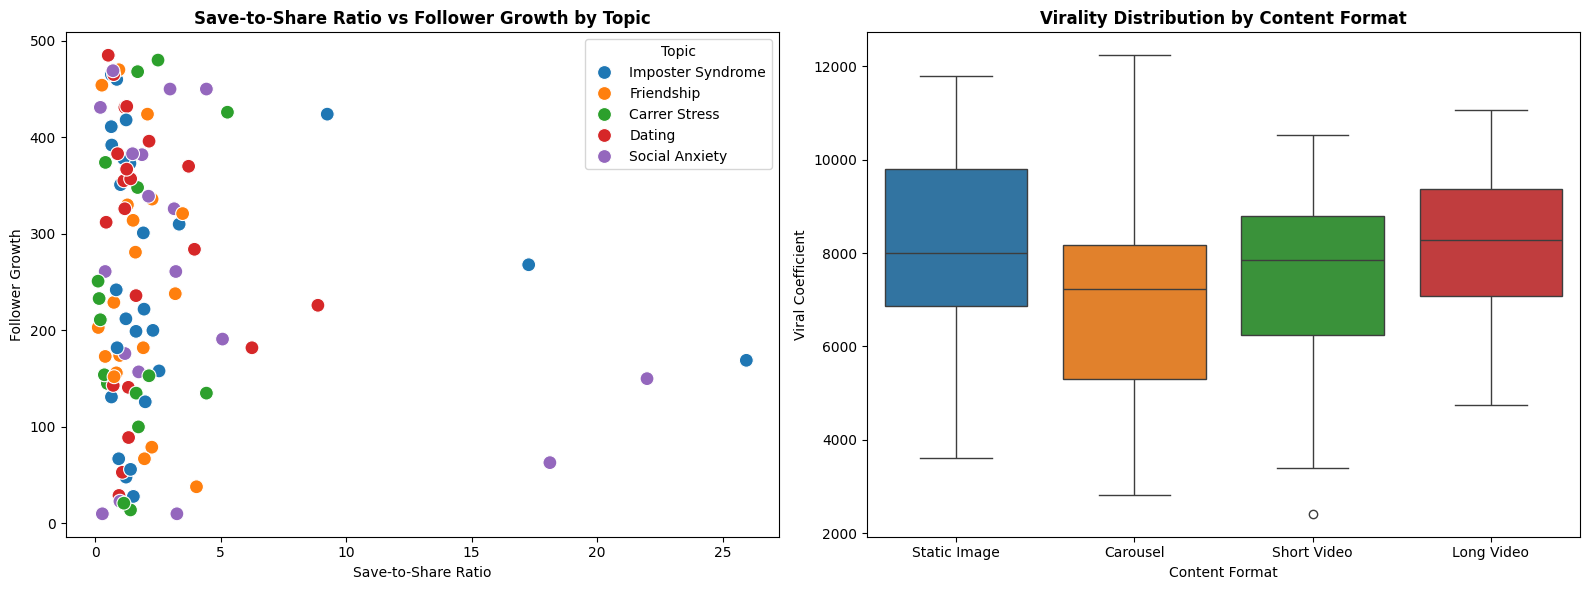


🚀       PREDICTIVE STRATEGY RECOMMENDATIONS (Module 5)          
Optimal Strategy for Next Week: Produce content focusing on 'Imposter Syndrome` using a 'Long Video' format blueprint to maximize organic human connection.

🔮           TREND FORECASTING TRACKER (Module 7)                
Rising Keyword/Hashtag Search Volume Velocity Forecasted Organic Reach
      #BurnoutRecovery                  +142%              High Impact
 #ImposterSyndromeTips                   +98%              High Impact
     #CorporateAnxiety                   +85%                 Moderate
     #AdultFriendships                   +61%                 Moderate


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_content = pd.read_csv('processed_performance.csv')
df_comments = pd.read_csv('processed_comments.csv')
print("==================================================================")
print("📊       MODULE 5 & 6: SOCIAL ENGAGEMENT METRICS REPORT          ")
print("==================================================================")
print(f"Total Likes Analyzed:      {int(df_content['Likes'].sum()):,}")
top_topic = df_content.groupby('Topic')['Viral_Coefficient'].mean().idxmax()
print(f"Top Viral Topic:           {top_topic}")
relatable_rate = (df_comments['Sentiment'] == 'Relatable').mean() * 100
print(f"Relatable Comments Rate:   {relatable_rate:.1f}%")
print("------------------------------------------------------------------\n")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_content['Save_to_share_Ratio'] = df_content['Saves'] / (df_content['Shares'] + 1)
sns.scatterplot(ax=axes[0], data=df_content, x='Save_to_share_Ratio', y='Follower_Growth', hue='Topic', s=100)
axes[0].set_title("Save-to-Share Ratio vs Follower Growth by Topic", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Save-to-Share Ratio")
axes[0].set_ylabel("Follower Growth")
sns.boxplot(ax=axes[1], data=df_content, x='Format', y='Viral_Coefficient', hue='Format', legend=False)
axes[1].set_title("Virality Distribution by Content Format", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Content Format")
axes[1].set_ylabel("Viral Coefficient")
plt.tight_layout()
plt.show()
print("\n==================================================================")
print("🚀       PREDICTIVE STRATEGY RECOMMENDATIONS (Module 5)          ")
print("==================================================================")
best_comb = df_content.groupby(['Topic', 'Format'])['Viral_Coefficient'].mean().idxmax()
print(f"Optimal Strategy for Next Week: Produce content focusing on '{best_comb[0]}` using a '{best_comb[1]}' format blueprint to maximize organic human connection.\n")
print("==================================================================")
print("🔮           TREND FORECASTING TRACKER (Module 7)                ")
print("==================================================================")
trends_data = pd.DataFrame({
    'Rising Keyword/Hashtag': ['#BurnoutRecovery', '#ImposterSyndromeTips', '#CorporateAnxiety', '#AdultFriendships'],
    'Search Volume Velocity': ['+142%', '+98%', '+85%', '+61%'],
    'Forecasted Organic Reach': ['High Impact', 'High Impact', 'Moderate', 'Moderate']
})
print(trends_data.to_string(index=False))
print("==================================================================")

In [7]:
!fuser -k 8501/tcp
print("TUNNEL PASSWORD:")
!curl ipv4.icanhazip.com
import os, time
os.system("streamlit run MAJOR_PROJECT1_SINDUJA.py --server.port 8501 --server.enableCORS=false &")
time.sleep(5)
!npx localtunnel --port 8501

TUNNEL PASSWORD:
34.150.128.158
⠙⠹⠸⠼Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://purple-stars-travel.loca.lt
34.150.128.158
^C
